In [2]:
import os

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import numpy as np

# Getting Data
data = fetch_openml(data_id=43939, as_frame=False, parser='auto')



# Feature Encoding - ocean proximity
ocean_proximity_map = {
    'ISLAND':     0,
    '<1H OCEAN':  1,
    'NEAR OCEAN': 2,
    'NEAR BAY':   3,
    'INLAND':     4,
}
mapper = np.vectorize(ocean_proximity_map.get)
data.data[:,8] = mapper(data.data[:,8])


X, y = data.data.astype(np.float32), data.target.astype(np.float32)

# Train-Val-Split 60/20/20
X_trainval, X_test, y_trainval, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


# Data Normalization
scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_trainval = scaler_X.fit_transform(X_trainval)
X_test  = scaler_X.transform(X_test)

y_trainval = scaler_y.fit_transform(y_trainval.reshape(-1, 1))
y_test  = scaler_y.transform(y_test.reshape(-1, 1))

#NaN problem
mask = ~np.isnan(X_test).any(axis=1)
X_test = X_test[mask]
y_test = y_test[mask] # Keep y in sync!

print(f"Train: {X_trainval.shape}, Test: {X_test.shape}")
print(f"Input_size: {X_trainval.shape[1]}")

Train: (12384, 9), Val: (4128, 9), Test: (3921, 9)
Input_size: 9


# Optuna Objective

In [6]:
from torch.utils.data import TensorDataset, DataLoader, Subset
from sklearn.model_selection import KFold
from MLPRegressor import MLPRegressor

import optuna
import torch
from torch import nn
from torch import optim


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def _train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    return avg_loss

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss

X_trainval_tensor = torch.from_numpy(X_trainval).float()
y_trainval_tensor = torch.from_numpy(y_trainval).float()
dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)


def nn_shape_objective(trial):
    global X_trainval, y_trainval, dataset

    N_EPOCHS = 10

    hidden_size = trial.suggest_int('hidden_size', 1, 512)
    n_hidden = trial.suggest_int('n_hidden', 1, 8)

    criterion = nn.MSELoss()
    kf = KFold(n_splits=5, shuffle=True, random_state=42)

    fold_loss = []
    for fold, (train_idx, val_idx) in enumerate(kf.split(X_trainval)):
        train_loader = DataLoader(
            Subset(dataset, train_idx), batch_size=256, shuffle=True
        )
        val_loader = DataLoader(
            Subset(dataset, val_idx), batch_size=256
        )

        model = MLPRegressor(input_size=X_trainval.shape[1], hidden_size=hidden_size, n_hidden=n_hidden, output_size=1).to(DEVICE)
        optimizer = optim.Adam(model.parameters(), lr=0.01)

        for epoch in range(N_EPOCHS):
            _train_one_epoch(model, train_loader, optimizer, criterion)

        fold_loss.append(_calculate_val_loss(model, val_loader, criterion))

    return float(np.mean(fold_loss))

study = optuna.create_study(direction='minimize')
study.optimize(nn_shape_objective, n_trials=50, show_progress_bar=True )

print("Best parameters:", study.best_params)
print("Mean avg val loss CV: ", study.best_value)

[I 2026-04-07 16:15:43,694] A new study created in memory with name: no-name-6728174e-97b4-4892-863b-49b2d5f6861a


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-07 16:16:14,148] Trial 0 finished with value: 0.2365709164967904 and parameters: {'hidden_size': 185, 'n_hidden': 7}. Best is trial 0 with value: 0.2365709164967904.
[I 2026-04-07 16:16:37,633] Trial 1 finished with value: 0.2475109512989338 and parameters: {'hidden_size': 24, 'n_hidden': 6}. Best is trial 0 with value: 0.2365709164967904.
[I 2026-04-07 16:17:02,873] Trial 2 finished with value: 0.23280830383300782 and parameters: {'hidden_size': 382, 'n_hidden': 4}. Best is trial 2 with value: 0.23280830383300782.
[I 2026-04-07 16:17:25,588] Trial 3 finished with value: 0.22959781793447642 and parameters: {'hidden_size': 109, 'n_hidden': 3}. Best is trial 3 with value: 0.22959781793447642.
[I 2026-04-07 16:17:43,437] Trial 4 finished with value: 0.2273871777149347 and parameters: {'hidden_size': 270, 'n_hidden': 1}. Best is trial 4 with value: 0.2273871777149347.
[I 2026-04-07 16:17:59,316] Trial 5 finished with value: 0.22906381785869598 and parameters: {'hidden_size': 206

In [ ]:
# best_params = {'hidden_size': 511, 'n_hidden': 1}

# Training Models

---FOLD 0 ---


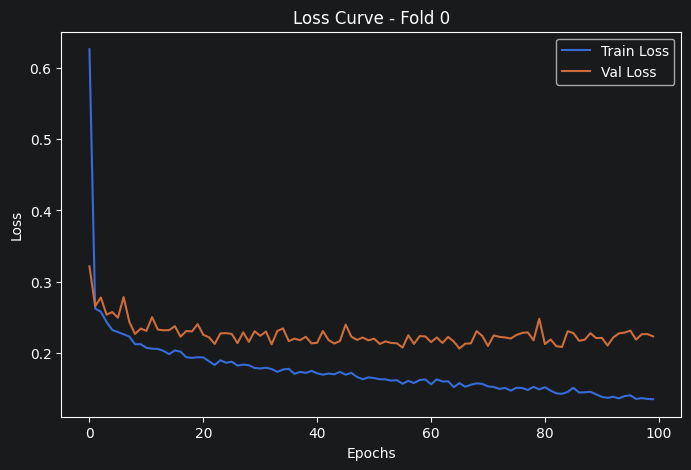

---FOLD 1 ---


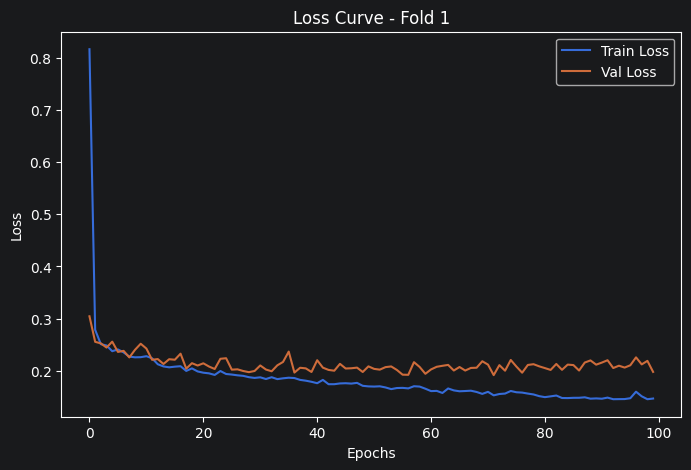

---FOLD 2 ---


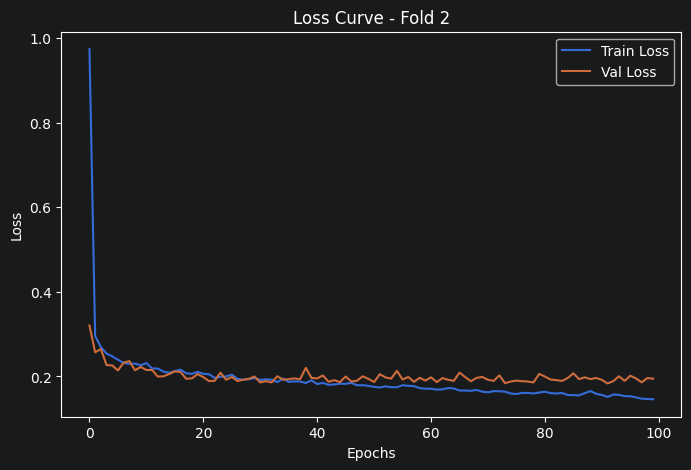

---FOLD 3 ---


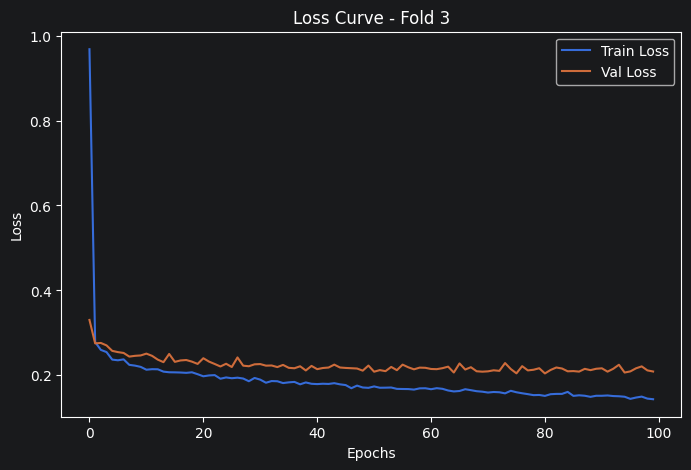

---FOLD 4 ---


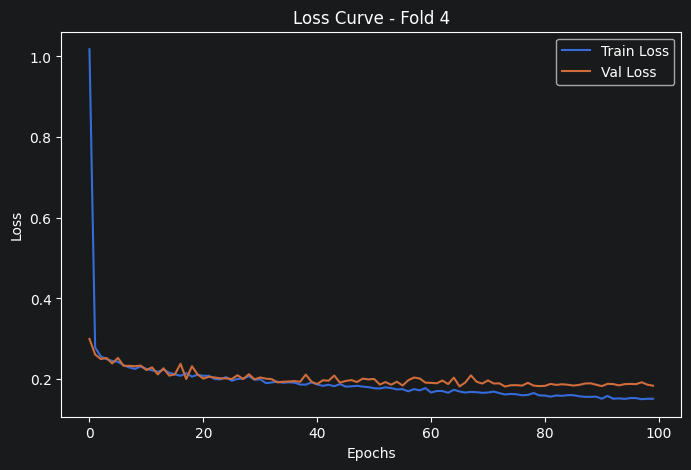

In [9]:
from MLPRegressor import MLPRegressor

import os
from matplotlib import pyplot as plt
from sklearn.model_selection import KFold

import torch
from torch import nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader, Subset



DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
def _train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss = 0.0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        loss = criterion(model(X), y)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(loader)
    return avg_loss

def _calculate_val_loss(model, loader, criterion):
    model.eval()
    running_loss = 0.0
    with torch.no_grad():
        for X,y in loader:
            X, y = X.to(DEVICE), y.to(DEVICE)
            output = model(X)
            loss = criterion(output, y)
            running_loss += loss.item()
    avg_loss = running_loss / len(loader)

    return avg_loss

# Saving Dir
PATH = os.path.join('Models','folds')
os.makedirs(PATH, exist_ok=True)

# Data Preparation
X_trainval_tensor = torch.from_numpy(X_trainval).float()
y_trainval_tensor = torch.from_numpy(y_trainval).float()
dataset = TensorDataset(X_trainval_tensor, y_trainval_tensor)

# Criterion and Folds
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
num_epochs = 100
batch_size = 256
lr = 0.01
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for fold, (train_index, val_index) in enumerate(kf.split(X_trainval)):
    print(f"---FOLD {fold} ---")
    # Fold Split and Loaders
    train_sample = Subset(dataset, train_index)
    val_sample = Subset(dataset, val_index)

    train_loader = DataLoader(train_sample, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_sample, batch_size=batch_size, shuffle=False)

    #Model, Optimizer and Loss
    model = MLPRegressor(input_size=X_trainval.shape[1],
                         hidden_size=study.best_params['hidden_size'],
                         n_hidden=study.best_params['n_hidden'],
                         output_size=1).to(DEVICE)

    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    best_val_loss = float("inf")
    history = {'train_loss':[], 'val_loss':[]}

    for epoch in range(num_epochs):
        train_loss = _train_one_epoch(model, train_loader, optimizer, criterion)
        val_loss = _calculate_val_loss(model, val_loader, criterion)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            checkpoint = {
                'epoch': epoch,
                'model_state': model.state_dict(),
                'optimizer_state': optimizer.state_dict(),
                'best_val_loss': best_val_loss,
                'history': history
            }
            save_path = os.path.join(PATH, f'model_{fold}.pth')
            torch.save(checkpoint, save_path)

    # Vizualization
    plt.figure(figsize=(8, 5))
    plt.plot(history['train_loss'], label='Train Loss')
    plt.plot(history['val_loss'], label='Val Loss')
    plt.title(f'Loss Curve - Fold {fold}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

# Mean response and model testing

In [12]:
import torch
from sklearn.metrics import mean_squared_error, r2_score

def mean_response(models: list[nn.Module], X: torch.Tensor) -> torch.Tensor:
    preds = []
    for model in models:
        model.eval()
        with torch.no_grad():
            preds.append(model(X).squeeze())

    return torch.stack(preds).mean(dim=0)


PATH = os.path.join('Models','folds')
models = []

for n in os.listdir(PATH):
    checkpoint = torch.load(os.path.join(PATH, n))
    m = MLPRegressor(input_size=X_trainval.shape[1],
                         hidden_size=study.best_params['hidden_size'],
                         n_hidden=study.best_params['n_hidden'],
                         output_size=1)
    m.load_state_dict(checkpoint['model_state'])
    models.append(m)


X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
pred = mean_response(models, X_test_tensor)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)

print(f"RMSE: {rmse:.4f}")
print(f"R2:   {r2:.4f}")

RMSE: 0.4248
R2:   0.8165
